In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_pickle('results.pkl')

In [4]:
df.head

<bound method NDFrame.head of      size  dimension  label_noise  feature_noise   svm_acc    lr_acc  \
0     500         50            0              0  0.867200  0.731200   
1     500         50            0             30  0.830400  0.648000   
2     500         50            0             60  0.774400  0.710400   
3     500         50           10              0  0.852800  0.716800   
4     500         50           10             30  0.793600  0.678400   
5     500         50           10             60  0.715200  0.683200   
6     500         50           20              0  0.760000  0.643200   
7     500         50           20             30  0.777600  0.603200   
8     500         50           20             60  0.729600  0.659200   
9     500         50           30              0  0.739200  0.656000   
10    500         50           30             30  0.683200  0.598400   
11    500         50           30             60  0.665600  0.608000   
12   2000         50            0 

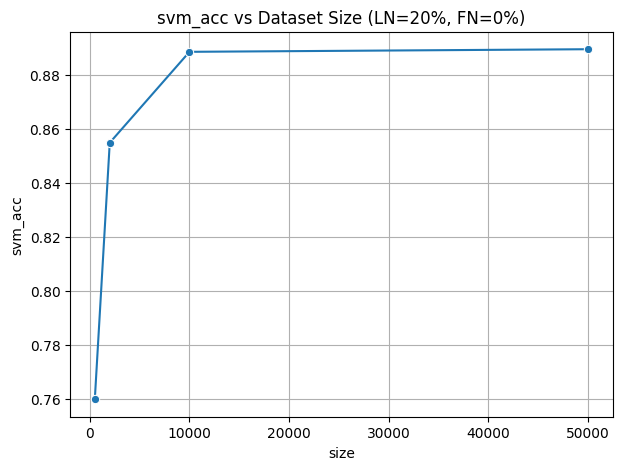

In [5]:
# plots
import matplotlib.pyplot as plt
import seaborn as sns

def plot_size_vs_accuracy(df, model="lr_f1", ln=30, fn=0):
    subset = df[(df.label_noise==ln) & (df.feature_noise==fn)]
    subset = subset.sort_values("size")

    plt.figure(figsize=(7,5))
    sns.lineplot(data=subset, x="size", y=model, marker="o")
    plt.title(f"{model} vs Dataset Size (LN={ln}%, FN={fn}%)")
    plt.grid()
    plt.show()

plot_size_vs_accuracy(df, "svm_acc", ln=20, fn=0)

# label Noise Vs Feature Noise Comparison

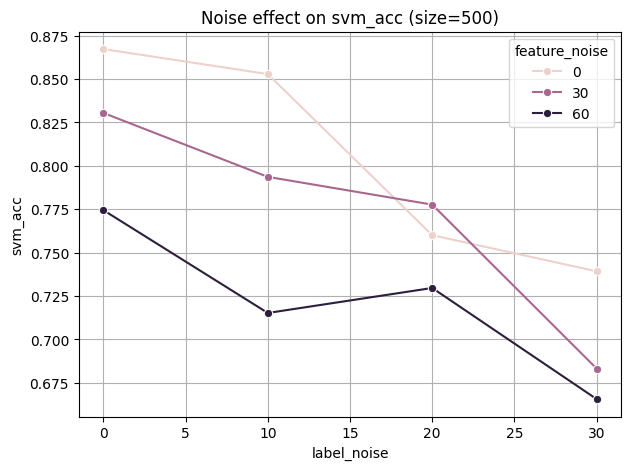

In [6]:
# Label vs Feature noise comparison

def plot_noise_comparison(df, model="svm_acc", size=10000):
    subset = df[df["size"]==size]

    plt.figure(figsize=(7,5))
    sns.lineplot(data=subset, x="label_noise", y=model, hue="feature_noise", marker="o")
    plt.title(f"Noise effect on {model} (size={size})")
    plt.grid()
    plt.show()

plot_noise_comparison(df, "svm_acc", size=500)
# plot_noise_comparison(df, "svm_acc", size=2000)
# plot_noise_comparison(df, "svm_acc", size=10000)
# plot_noise_comparison(df, "svm_acc", size=50000)

# plot_noise_comparison(df, "lr_acc", size=500)
# plot_noise_comparison(df, "lr_acc", size=2000)
# plot_noise_comparison(df, "lr_acc", size=10000)
# plot_noise_comparison(df, "lr_acc", size=50000)

# plot_noise_comparison(df, "rf_acc", size=500)
# plot_noise_comparison(df, "rf_acc", size=2000)
# plot_noise_comparison(df, "rf_acc", size=10000)
# plot_noise_comparison(df, "rf_acc", size=50000)



In [7]:
df['size'].unique()

array([  500,  2000, 10000, 50000])

In [8]:
df['label_noise'].unique()

array([ 0, 10, 20, 30])

In [9]:
df['feature_noise'].unique()

array([ 0, 30, 60])

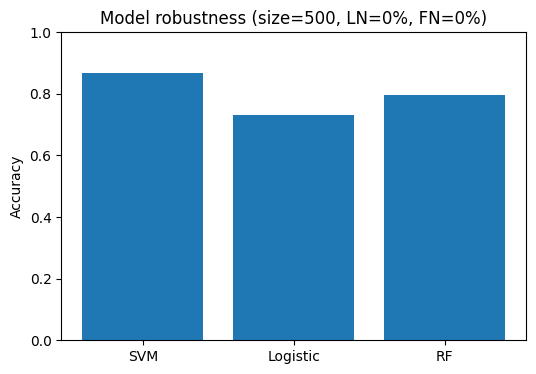

In [10]:
# Model robustness comparison

def plot_model_comparison(df, size=50000, ln=30, fn=60):

    subset = df[
        (df["size"] == size) &
        (df["label_noise"].round(0) == ln) &
        (df["feature_noise"].round(0) == fn)
    ]

    if subset.empty:
        print("No matching row found. Available combinations:")
        print(df[["size","label_noise","feature_noise"]].drop_duplicates())
        return

    values = subset[["svm_acc","lr_acc","rf_acc"]].iloc[0]

    plt.figure(figsize=(6,4))
    plt.bar(["SVM","Logistic","RF"], values)
    plt.title(f"Model robustness (size={size}, LN={ln}%, FN={fn}%)")
    plt.ylabel("Accuracy")
    plt.ylim(0,1)
    plt.show()


plot_model_comparison(df, 500, 0, 0)
# plot_model_comparison(df, 2000, 0, 0)
# plot_model_comparison(df, 10000, 0, 0)
# plot_model_comparison(df, 50000, 0, 0)

# plot_model_comparison(df, 500, 0, 30)
# plot_model_comparison(df, 2000, 0, 30)
# plot_model_comparison(df, 10000, 0, 30)
# plot_model_comparison(df, 50000, 0, 30)

# plot_model_comparison(df, 500, 0, 60)
# plot_model_comparison(df, 2000, 0, 60)
# plot_model_comparison(df, 10000, 0, 60)
# plot_model_comparison(df, 50000, 0, 60)

# plot_model_comparison(df, 500, 10, 0)
# plot_model_comparison(df, 2000, 10, 0)
# plot_model_comparison(df, 10000, 10, 0)
# plot_model_comparison(df, 50000, 10, 0)

# plot_model_comparison(df, 500, 10, 30)
# plot_model_comparison(df, 2000, 10, 30)
# plot_model_comparison(df, 10000, 10, 30)
# plot_model_comparison(df, 50000, 10, 30)

# plot_model_comparison(df, 500, 10, 60)
# plot_model_comparison(df, 2000, 10, 60)
# plot_model_comparison(df, 10000, 10, 60)
# plot_model_comparison(df, 50000, 10, 60)

# plot_model_comparison(df, 500, 20, 0)
# plot_model_comparison(df, 2000, 20, 0)
# plot_model_comparison(df, 10000, 20, 0)
# plot_model_comparison(df, 50000, 20, 0)

# plot_model_comparison(df, 500, 20, 30)
# plot_model_comparison(df, 2000, 20, 30)
# plot_model_comparison(df, 10000, 20, 30)
# plot_model_comparison(df, 50000, 20, 30)

# plot_model_comparison(df, 500, 20, 60)
# plot_model_comparison(df, 2000, 20, 60)
# plot_model_comparison(df, 10000, 20, 60)
# plot_model_comparison(df, 50000, 20, 60)

# plot_model_comparison(df, 500, 30, 0)
# plot_model_comparison(df, 2000, 30, 0)
# plot_model_comparison(df, 10000, 30, 0)
# plot_model_comparison(df, 50000, 30, 0)

# plot_model_comparison(df, 500, 30, 30)
# plot_model_comparison(df, 2000, 30, 30)
# plot_model_comparison(df, 10000, 30, 30)
# plot_model_comparison(df, 50000, 30, 30)

# plot_model_comparison(df, 500, 30, 60)
# plot_model_comparison(df, 2000, 30, 60)
# plot_model_comparison(df, 10000, 30, 60)
# plot_model_comparison(df, 50000, 30, 60)